In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def compute_position_score(df):
    # Convert each serial_position_score string into a list of integers
    scores = df["serial_position_score"].apply(
        lambda x: [int(v) for v in x.split()]
    )
    # Put all rows into a matrix
    score_matrix = pd.DataFrame(scores.tolist())

    # Mean at each position = proportion of correct recalls
    accuracy_by_position = score_matrix.mean(axis=0)
    return accuracy_by_position

def smooth_graph(graph_list):
    return [(graph_list[i] + graph_list[i-1] + graph_list[i+1])/3 for i in range(1,len(graph_list)-1)]

In [ ]:
def plot_accuracy_by_position(accuracy_by_position: list, legends: list):
    for i in range(len(accuracy_by_position)):
        plt.plot(
            range(1, len(accuracy_by_position[i]) + 1),
            accuracy_by_position[i],
            marker="o",
            label=legends[i]
        )

    plt.xlabel("Serial position")
    plt.ylabel("Proportion correct")
    plt.title("Recall accuracy by serial position")
    plt.xticks(range(1, len(accuracy_by_position[0]) + 1))
    plt.ylim(-0.1, 1.1)
    plt.grid(axis="y")
    plt.legend()
    plt.show()

In [ ]:
df_base = pd.read_csv("Result/free_recall_baseline_Katinka.csv")
acc_base = compute_position_score(df_base)
acc_base_smooth = smooth_graph(acc_base)

In [57]:
df_1A = pd.read_csv("Result/1A_Katinka.csv")
acc_1A = compute_position_score(df_1A)
acc_1A_smooth = smooth_graph(acc_1A)

In [58]:
df_1B = pd.read_csv("Result/1B_Katinka.csv")
acc_1B = compute_position_score(df_1B)
acc_1B_smooth = smooth_graph(acc_1B)

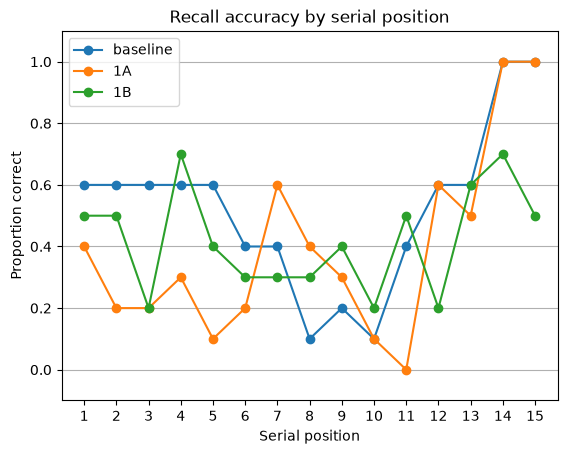

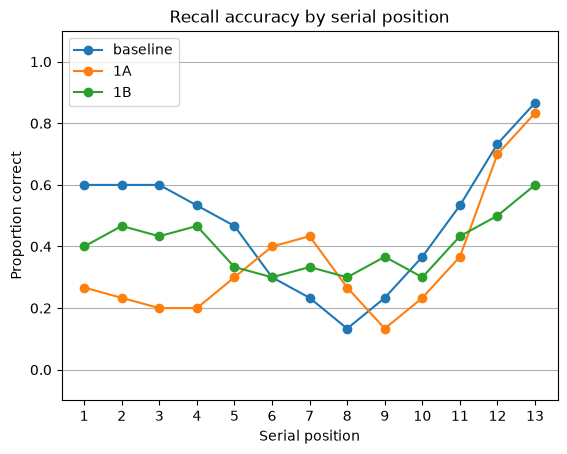

In [63]:
plot_accuracy_by_position([acc_base, acc_1A, acc_1B], ["baseline", "1A", "1B"])
plot_accuracy_by_position([acc_base_smooth, acc_1A_smooth, acc_1B_smooth], ["baseline", "1A", "1B"])